<a href="https://colab.research.google.com/github/qaadhare-tip/CPE-018-CPE31S2---Emerging-Technologies-1-in-CpE/blob/main/Activity_7_Performing_Face_Recognition_(Hare%2C_Andrei_Angelo_D_).ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Technological Institute of the Philippines | Quezon City - Computer Engineering
--- | ---
Course Code: | CPE 018
Code Title: | Emerging Technologies in CpE 1 - Fundamentals of Computer Vision
2nd Semester | AY 2025-2026
<hr> | <hr>
<u>**ACTIVITY NO 6.1** | **Hands-on Activity 6.1 Performing Face Recognition **
**Name** | Hare, Andrei Angelo
**Section** | CPE31S2
**Date Performed**: | 3/3/2026
**Date Submitted**: |
**Instructor**: | Engr. Maria Rizette Sayo

<hr>

In [5]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


This activity aims to enable students to perform data preparation and face recognition on their own generated dataset.

## 2. Intended Learning Outcomes (ILOs)
After this activity, the students should be able to:
* Utilize data preparation techniques for images.
* Perform Face Recognition using multiple algorithms.
* Evaluate the performance of different algorithms.

## 3. Procedures and Outputs

## 1. Objectives

### Preparing the training data

Now that we have our data, we need to load these sample pictures into our face recognition algorithms. All face recognition algorithms take two parameters in their `train()` method: an array of images and an array of labels. What do these labels represent? They are the IDs of a certain individual/face so that when face recognition is performed, we not only know the person was recognized but also who—among the many people available in our database—the person is.

To do that, we need to create a comma-separated value (CSV) file, which will contain the path to a sample picture followed by the ID of that person.

**Include a Screenshot of Your Dataset Here**

---

### Loading the data and recognizing faces

Next up, we need to load these two resources (the array of images and CSV file) into the face recognition algorithm, so it can be trained to recognize our face. To do this, we build a function that reads the CSV file and—for each line of the file—loads the image at the corresponding path into the images array and the ID into the labels array.

In [13]:
import numpy as np
import os
import errno
import sys
import cv2

def read_images(path, sz=None):
  c = 0
  X, y = [], []

  for dirname, dirnames, filenames in os.walk(path):
    for subdirname in dirnames:
      subject_path = os.path.join(dirname, subdirname)
      for filename in os.listdir(subject_path):
        try:
          if(filename == "/content/drive/MyDrive/Colab Notebooks/opencvdataset/person_1test.jpg"):
            continue
          filepath = os.path.join(subject_path, filename)
          im = cv2.imread(os.path.join(subject_path, filename), cv2.IMREAD_GRAYSCALE)

          # Resize the images to the prescribed size
          if (sz is not None):
            im = cv2.resize(im, (200,200))

          X.append(np.asarray(im, dtype=np.uint8))
          y.append(c)

        except IOError as e:
          print(f"I/O Error({e.errno}): {e.strerror}")
        except:
          print("Unexpected error:", sys.exc_info()[0])
          raise
      c = c+1
  return [X, y]

**Question: Run the function above on your generated dataset. Provide an analysis and note all the challenges you have encountered running this code.**

---

### Performing Face Recognition Algorithms

Here is a sample script for testing the Face Recognition Algorithm. In this section, we're going to follow the same process but with different algorithms for face recognitions, namely:
- Eigenface Recognition
- Fisherface Recognition
- Local Binary Pattern Histograms (LBPH) Recognition

In [41]:
def face_rec():
  names = ['person_1test']

  dataset_path = "/content/drive/MyDrive/Colab Notebooks/Human faces and object dataset"

  if not os.path.isdir(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found or is not a directory.")
    print("Please ensure you have mounted Google Drive and updated 'dataset_path' to your image dataset's location.")
    return # Exit the function if the path is invalid

  [X, y] = read_images(dataset_path)

  if not X:
    print(f"Error: No images were loaded from '{dataset_path}'.")
    print("Please check if the path is correct and if the directory contains subfolders with images.")
    return

  y = np.asarray(y, dtype=np.int32)

  model = cv2.face.EigenFaceRecognizer_create()
  model.train(X, y)

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

  while True:
    ret, img = camera.read()
    if not ret:
      break

    faces = face_cascade.detectMultiScale(img, 1.3, 5)

    for (x, y, w, h) in faces:
      cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
      gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
      roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR)

      try:
        params = model.predict(roi)
        label = names[params[0]]
        cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
      except:
        continue

    cv2.imshow("camera", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
  face_rec()


Reading folder: Images
Could not read: /content/drive/MyDrive/Colab Notebooks/Human faces and object dataset/Images/female_faces
Could not read: /content/drive/MyDrive/Colab Notebooks/Human faces and object dataset/Images/Objects
Could not read: /content/drive/MyDrive/Colab Notebooks/Human faces and object dataset/Images/male_faces
Error: No images were loaded from '/content/drive/MyDrive/Colab Notebooks/Human faces and object dataset'.
Please check if the path is correct and if the directory contains subfolders with images.


**Question: Provide an analysis of the sample script for the process using the Eigenface Model. What is the sample code doing? Are you able to troubleshoot any problems encountered?**

The sample code trains an Eigenface model using a dataset and performs live face recognition using a webcam. The error shows that no images were successfully loaded from the dataset path. The issue is most likely related to an incorrect folder structure, wrong path, or missing images. Fixing the dataset location and structure should solve the problem.

---
Perform the remaining face recognition techniques by using the same (or modified) process from the sample code:

- `model = cv2.face.createFisherFaceRecognizer()`
- `model = cv2.face.createLBPHFaceRecognizer()`

In [36]:
def face_rec():
  names = ['person_2test']

  dataset_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset"

  if not os.path.isdir(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found or is not a directory.")
    print("Please ensure you have mounted Google Drive and updated 'dataset_path' to your image dataset's location.")
    return # Exit the function if the path is invalid

  [X, y] = read_images(dataset_path)

  if not X:
    print(f"Error: No images were loaded from '{dataset_path}'.")
    print("Please check if the path is correct and if the directory contains subfolders with images.")
    return

  y = np.asarray(y, dtype=np.int32)

  model = cv2.face.createFisherFaceRecognizer_create()
  model.train(X, y)

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

  while True:
    ret, img = camera.read()
    if not ret:
      break

    faces = face_cascade.detectMultiScale(img, 1.3, 5)

    for (x, y, w, h) in faces:
      cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
      gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
      roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR)

      try:
        params = model.predict(roi)
        label = names[params[0]]
        cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
      except:
        continue

    cv2.imshow("camera", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
  face_rec()

Error: No images were loaded from '/content/drive/MyDrive/Colab Notebooks/opencvdataset'.
Please check if the path is correct and if the directory contains subfolders with images.


In [37]:
def face_rec():
  names = ['person_2test']

  dataset_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset"

  if not os.path.isdir(dataset_path):
    print(f"Error: Dataset path '{dataset_path}' not found or is not a directory.")
    print("Please ensure you have mounted Google Drive and updated 'dataset_path' to your image dataset's location.")
    return # Exit the function if the path is invalid

  [X, y] = read_images(dataset_path)

  if not X:
    print(f"Error: No images were loaded from '{dataset_path}'.")
    print("Please check if the path is correct and if the directory contains subfolders with images.")
    return

  y = np.asarray(y, dtype=np.int32)

  model = cv2.face.createLBPHFaceRecognizer_create()
  model.train(X, y)

  camera = cv2.VideoCapture(0)
  face_cascade = cv2.CascadeClassifier('haarcascade_frontalface_default.xml')

  while True:
    ret, img = camera.read()
    if not ret:
      break

    faces = face_cascade.detectMultiScale(img, 1.3, 5)

    for (x, y, w, h) in faces:
      cv2.rectangle(img, (x, y), (x + w, y + h), (255, 0, 0), 2)
      gray = cv2.cvtColor(img[y:y + h, x:x + w], cv2.COLOR_BGR2GRAY)
      roi = cv2.resize(gray, (200, 200), interpolation=cv2.INTER_LINEAR)

      try:
        params = model.predict(roi)
        label = names[params[0]]
        cv2.putText(img, label + ", " + str(params[1]), (x, y - 20), cv2.FONT_HERSHEY_SIMPLEX, 1, (255, 0, 0), 2)
      except:
        continue

    cv2.imshow("camera", img)
    if cv2.waitKey(1) & 0xFF == ord("q"):
      break

  camera.release()
  cv2.destroyAllWindows()

if __name__ == "__main__":
  face_rec()

Error: No images were loaded from '/content/drive/MyDrive/Colab Notebooks/opencvdataset'.
Please check if the path is correct and if the directory contains subfolders with images.


**Question: The `predict()` method returns a two-element array. Provide your analysis of the two returned values and their important ince this application.**

Answer:

The `predict()` method returns two main values:

Predicted Label (ID): This is an integer that represents the recognized person. It matches the ID assigned during the training.

Confidence Score (or Distance): This shows how sure the model is about its prediction. For Eigenfaces, Fisherfaces, and LBPH, a lower score means higher confidence. This is important for filtering wrong predictions and setting a recognition threshold.


## 4. Supplementary Activity

Your accomplisment of the tasks below contribute to the achievement of ILO1, ILO2, and ILO3 for this module.

---

Tasks:
1. Create a new dataset for testing, this dataset must include the following:
  - The same person/s that the model has to recognize.
  - Different person/s that the model should not recognize.
2. For each model, perform 20 tests. Document the testing performed and provide observations.
3. Conclude on the performed tests by providing your evaluation of the performance of the models.

In [32]:
from google.colab import drive
drive.mount('/content/drive')
dataset_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset"

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


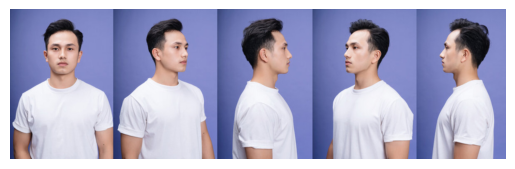

In [38]:
import cv2
import matplotlib.pyplot as plt

image_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset/person_1test.jpg"

img = cv2.imread(image_path)
img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

plt.imshow(img)
plt.axis("off")
plt.show()

In [20]:
import os
dataset_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset"
print("Inside dataset:", os.listdir(dataset_path))

Inside dataset: ['generate-realistic-human-face-using-gan.ipynb', 'person_1test.jpg']


In [39]:
import numpy as np
import os
import cv2

def read_images(path, sz=None):
    X, y = [], []

    if not os.path.exists(path):
        print("Dataset path does NOT exist!")
        return X, y

    label = 0

    for folder_name in sorted(os.listdir(path)):
        folder_path = os.path.join(path, folder_name)

        if not os.path.isdir(folder_path):
            continue

        print("Reading folder:", folder_name)

        for filename in os.listdir(folder_path):

            if filename.startswith("."):
                continue

            filepath = os.path.join(folder_path, filename)

            im = cv2.imread(filepath, cv2.IMREAD_GRAYSCALE)

            if im is None:
                print("Could not read:", filepath)
                continue

            if sz is not None:
                im = cv2.resize(im, sz)

            X.append(im)
            y.append(label)

        label += 1

    return X, y

In [22]:
import os
for root, dirs, files in os.walk(dataset_path):
    print("ROOT:", root)
    print("DIRS:", dirs)
    print("FILES:", files)
    print("------")

ROOT: /content/drive/MyDrive/Colab Notebooks/opencvdataset
DIRS: []
FILES: ['generate-realistic-human-face-using-gan.ipynb', 'person_1test.jpg']
------


In [40]:
import numpy as np
import cv2
import os
from google.colab.patches import cv2_imshow

def face_rec(dataset_path):

    names = ['Friend1', 'Friend2']  #inside data set

    # Load training data
    X, y = read_images(dataset_path, sz=(200,200))
    y = np.asarray(y, dtype=np.int32)


    model = cv2.face.EigenFaceRecognizer_create()
    model.train(X, y)


    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + 'haarcascade_frontalface_default.xml'
    )


    test_image_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset/person_1test.jpg"
    img = cv2.imread(test_image_path)

    if img is None:
        print("Test image not found!")
        return

    gray_full = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)
    faces = face_cascade.detectMultiScale(gray_full, 1.3, 5)

    for (x, y_pos, w, h) in faces:
        face = gray_full[y_pos:y_pos+h, x:x+w]
        roi = cv2.resize(face, (200, 200))

        label, confidence = model.predict(roi)

        cv2.rectangle(img, (x, y_pos), (x+w, y_pos+h), (255,0,0), 2)
        cv2.putText(img,
                    names[label] + " " + str(round(confidence,2)),
                    (x, y_pos-10),
                    cv2.FONT_HERSHEY_SIMPLEX,
                    0.8,
                    (255,0,0),
                    2)

    cv2_imshow(img)

In [26]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


Image loaded!


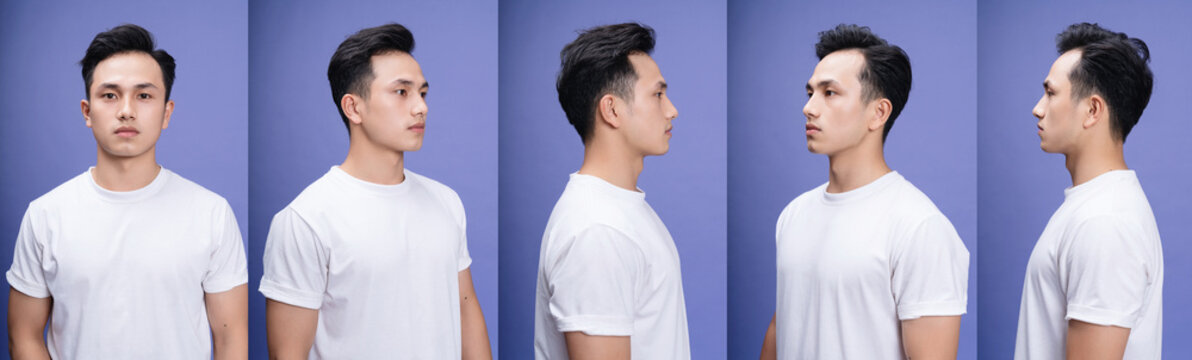

In [27]:
from google.colab.patches import cv2_imshow
import cv2

test_image_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset/person_1test.jpg"

img = cv2.imread(test_image_path)

if img is None:
    print("Image not found!")
else:
    print("Image loaded!")
    cv2_imshow(img)

In [30]:
print("Faces detected:", len(faces))

Faces detected: 4


Faces detected: 4


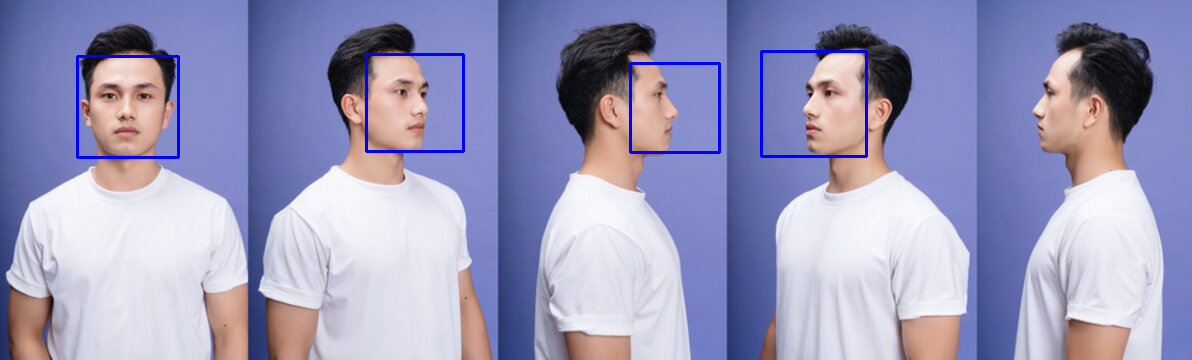

In [29]:


from google.colab.patches import cv2_imshow
import cv2

image_path = "/content/drive/MyDrive/Colab Notebooks/opencvdataset/person_1test.jpg"

img = cv2.imread(image_path)

if img is None:
    print("Image not found!")
else:
    gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

    face_cascade = cv2.CascadeClassifier(
        cv2.data.haarcascades + "haarcascade_frontalface_default.xml"
    )

    faces = face_cascade.detectMultiScale(
        gray,
        scaleFactor=1.1,
        minNeighbors=5
    )

    print("Faces detected:", len(faces))

    for (x, y, w, h) in faces:
        cv2.rectangle(img, (x, y), (x+w, y+h), (255, 0, 0), 2)

    cv2_imshow(img)

## 5. Summary, Conclusions and Lessons Learned

In this activity, We performed face recognition using OpenCV with Eigenfaces, Fisherfaces, and LBPH methods. These methods were trained using image datasets to identify a person’s face. Face recognition is more complex than face detection because it identifies the person, not just detects the face. As beginners, it was challenging but understandable.


<hr/>

***Proprietary Clause***

*Property of the Technological Institute of the Philippines (T.I.P.). No part of the materials made and uploaded in this learning management system by T.I.P. may be copied, photographed, printed, reproduced, shared, transmitted, translated, or reduced to any electronic medium or machine-readable form, in whole or in part, without the prior consent of T.I.P.*